In [1]:
import re
import time
import warnings

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import spacy
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from scipy.spatial.distance import cosine
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from unidecode import unidecode

import numpy as np

warnings.filterwarnings("ignore")


def ensure_stop_words_downloaded():
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")


def ensure_punkt_tab_downloaded():
    try:
        nltk.data.find("tokenizers/punkt")
    except LookupError:
        nltk.download("punkt")


ensure_stop_words_downloaded()
ensure_punkt_tab_downloaded()

In [2]:
corpus = [
    "Le machine learning est une branche de l'intelligence artificielle",
    "L'intelligence artificielle révolutionne les technologies modernes",
    "Les réseaux de neurones sont au cœur du deep learning",
    "Le deep learning utilise les réseaux de neurones profonds",
    "Les algorithmes d'apprentissage automatique traitent les données",
    "L'apprentissage profond demande beaucoup de données et de puissance calcul",
    "Les embeddings denses représentent les mots dans un espace continu",
    "La similarité cosinus mesure la proximité entre vecteurs",
    "Les modèles pré-entraînés accélèrent le développement",
    "Word2Vec génère des embeddings en capturant le contexte sémantique",
]

## Tâches

### Tâche 1 : Préparation des données
1. Nettoyez le corpus (utilisez l'exercice 1)
2. Tokenisez en phrases et tokens
3. Créez une liste de listes de tokens
4. Explorez la structure : nombre de phrases, moyenne de tokens par phrase

**Attendus** : Corpus préparé prêt pour Word2Vec

In [3]:
nlp = spacy.load("fr_core_news_sm")
french_stopwords = stopwords.words("french")


def preprocess1(text):
    text = text.lower()
    text = unidecode(text)
    text = re.sub(r"[^\w\s-]", " ", text)
    tokens = text.split(" ")
    tokens = [token for token in tokens if token not in french_stopwords]
    return " ".join(tokens)


def preprocess2(text):
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        if token.is_punct or token.is_space:
            continue
        lemma = token.lemma_.lower()
        if lemma in french_stopwords:
            continue
        tokens.append(lemma)
    return " ".join(tokens)


corpus_clean = []
for sentence in corpus:
    corpus_clean.append(preprocess1(sentence))

corpus_tokenize = [doc.split() for doc in corpus_clean]

print(f"Taille du corpus : {len(corpus_clean)} phrases")
print(f"Nombre de tokens pas phrase : {[len(tokens) for tokens in corpus_tokenize]}")
print(
    f"Moyenne de token par phrase : {np.mean([len(tokens) for tokens in corpus_tokenize])}"
)


Taille du corpus : 10 phrases
Nombre de tokens pas phrase : [5, 5, 5, 6, 5, 7, 6, 6, 4, 6]
Moyenne de token par phrase : 5.5


### Tâche 2 : Entraînement Skip-gram
1. Entraînez un modèle Word2Vec avec :
   - `sg=1` (Skip-gram)
   - `vector_size=100` (dimension des embeddings)
   - `window=5` (contexte)
   - `min_count=1` (accepter les mots uniques)
   - `epochs=20`
2. Affichez les paramètres du modèle
3. Extrayez l'embedding du mot "apprentissage"
4. Visualisez la forme : (nombre de mots, 100)

**Attendus** : Modèle Skip-gram entraîné, embedding d'un mot

In [4]:
t0 = time.time()
word_to_vec_skip_gram = Word2Vec(
    sentences=corpus_tokenize,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    epochs=20,
)
t1 = time.time()

print("Paramètres du moddèle Word2Vec :")
print("  vector_size:", word_to_vec_skip_gram.vector_size)
print("  window:", word_to_vec_skip_gram.window)
print("  min_count:", word_to_vec_skip_gram.min_count)
print("  sg:", "Skip-gram" if word_to_vec_skip_gram.sg else "CBOW")
print("  epochs:", word_to_vec_skip_gram.epochs)

print(
    f"\nFeatures ({len(word_to_vec_skip_gram.wv.index_to_key)}) : ",
    word_to_vec_skip_gram.wv.index_to_key,
)
print(f"Temps d'exécution : {t1 - t0} secondes")

word = "apprentissage"
print(f"\nEmbedding du mot '{word}' : ")
print(word_to_vec_skip_gram.wv[word])

Paramètres du moddèle Word2Vec :
  vector_size: 100
  window: 5
  min_count: 1
  sg: Skip-gram
  epochs: 20

Features (45) :  ['learning', 'embeddings', 'donnees', 'apprentissage', 'deep', 'neurones', 'reseaux', 'artificielle', 'intelligence', 'semantique', 'contexte', 'capturant', 'genere', 'word2vec', 'developpement', 'accelerent', 'pre-entraines', 'modeles', 'vecteurs', 'entre', 'proximite', 'mesure', 'cosinus', 'similarite', 'continu', 'espace', 'mots', 'representent', 'denses', 'calcul', 'puissance', 'beaucoup', 'demande', 'profond', 'traitent', 'automatique', 'algorithmes', 'profonds', 'utilise', 'coeur', 'modernes', 'technologies', 'revolutionne', 'branche', 'machine']
Temps d'exécution : 0.026593446731567383 secondes

Embedding du mot 'apprentissage' : 
[-8.2441783e-03  9.3000457e-03 -1.8883125e-04 -1.9583164e-03
  4.5847595e-03 -4.1022603e-03  2.7562077e-03  6.9471067e-03
  6.0665971e-03 -7.5251153e-03  9.3887616e-03  4.6627247e-03
  3.9790617e-03 -6.2512732e-03  8.4601520e-03

### Tâche 3 : Entraînement CBOW
1. Entraînez un modèle Word2Vec avec :
   - `sg=0` (CBOW)
   - Mêmes paramètres que Skip-gram
2. Comparez les embeddings avec Skip-gram :
   - Embeddings identiques?
   - Performances différentes?
   - Avantages/inconvénients de chaque approche?

**Attendus** : Modèle CBOW, comparaison avec Skip-gram

In [5]:
t2 = time.time()
word_to_vec_cbow = Word2Vec(
    sentences=corpus_tokenize,
    vector_size=100,
    window=5,
    min_count=1,
    sg=0,
    epochs=20,
)
t3 = time.time()

print("Paramètres du moddèle Word2Vec :")
print("  vector_size:", word_to_vec_cbow.vector_size)
print("  window:", word_to_vec_cbow.window)
print("  min_count:", word_to_vec_cbow.min_count)
print("  sg:", "Skip-gram" if word_to_vec_cbow.sg else "CBOW")
print("  epochs:", word_to_vec_cbow.epochs)

print(
    f"\nFeatures ({len(word_to_vec_cbow.wv.index_to_key)}) : ",
    word_to_vec_cbow.wv.index_to_key,
)
print(f"Temps d'exécution : {t3 - t2} secondes")

word = "apprentissage"
print(f"\nEmbedding du mot '{word}' : ")
print(word_to_vec_cbow.wv[word])

Paramètres du moddèle Word2Vec :
  vector_size: 100
  window: 5
  min_count: 1
  sg: CBOW
  epochs: 20

Features (45) :  ['learning', 'embeddings', 'donnees', 'apprentissage', 'deep', 'neurones', 'reseaux', 'artificielle', 'intelligence', 'semantique', 'contexte', 'capturant', 'genere', 'word2vec', 'developpement', 'accelerent', 'pre-entraines', 'modeles', 'vecteurs', 'entre', 'proximite', 'mesure', 'cosinus', 'similarite', 'continu', 'espace', 'mots', 'representent', 'denses', 'calcul', 'puissance', 'beaucoup', 'demande', 'profond', 'traitent', 'automatique', 'algorithmes', 'profonds', 'utilise', 'coeur', 'modernes', 'technologies', 'revolutionne', 'branche', 'machine']
Temps d'exécution : 0.027457237243652344 secondes

Embedding du mot 'apprentissage' : 
[-8.2368478e-03  9.2955539e-03 -1.8807217e-04 -1.9594589e-03
  4.5984322e-03 -4.0983837e-03  2.7475366e-03  6.9464752e-03
  6.0700700e-03 -7.5222393e-03  9.3871066e-03  4.6663857e-03
  3.9718542e-03 -6.2498334e-03  8.4549943e-03 -2.1

In [6]:
print(
    "Moyenne des différences en valeur absolue des embeddings : ",
    np.mean(
        [
            abs(word_to_vec_skip_gram.wv[word] - word_to_vec_cbow.wv[word])
            for word in word_to_vec_skip_gram.wv.index_to_key
        ]
    ),
)

print("\nComparaison temps d'exécution :")
print("Temps d'éxécution Skip-gram : ", t1 - t0)
print("Temps d'éxécution CBOW : ", t3 - t2)

Moyenne des différences en valeur absolue des embeddings :  8.935095e-06

Comparaison temps d'exécution :
Temps d'éxécution Skip-gram :  0.026593446731567383
Temps d'éxécution CBOW :  0.027457237243652344


### Tâche 4 : Similarité et opérations sémantiques
1. Calculez la similarité cosinus entre :
   - "machine learning" et "apprentissage automatique"
   - "deep learning" et "réseaux neuronaux"
   - "apprentissage" et "données"
2. Trouvez les 5 mots les plus similaires à "intelligence artificielle"
3. Trouvez les 5 mots les plus dissimilaires
4. Testez les analogies Word2Vec : "intelligence" - "artificielle" + "machine" ≈ ?

**Attendus** : Scores de similarité, mots similaires, analogies sémantiques

In [47]:
def add_bigrams(corpus):
    corpus_bigram = []
    for sentence in corpus:
        bigrams = [
            sentence[i] + " " + sentence[i + 1] for i in range(len(sentence) - 1)
        ]
        corpus_bigram.append(sentence + bigrams)
    return corpus_bigram


corpus_bigram = add_bigrams(corpus_tokenize)

word_to_vec_bigram = Word2Vec(
    sentences=corpus_bigram,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    epochs=20,
)

In [48]:
print(
    f"Similarite(machine learning, apprentissage automatique) = {word_to_vec_bigram.wv.similarity('machine learning', 'apprentissage automatique'):.4f}"
)
print(
    f"Similarite(deep learning, reseaux neurones) = {word_to_vec_bigram.wv.similarity('deep learning', 'reseaux neurones'):.4f}"
)
print(
    f"Similarite(apprentissage, donnees) = {word_to_vec_bigram.wv.similarity('apprentissage', 'donnees'):.4f}"
)

Similarite(machine learning, apprentissage automatique) = 0.0575
Similarite(deep learning, reseaux neurones) = 0.1487
Similarite(apprentissage, donnees) = -0.0046


In [49]:
similarities = []
for word in word_to_vec_bigram.wv.index_to_key:
    similarities.append(
        word_to_vec_bigram.wv.similarity("intelligence artificielle", word)
    )

similarities_df = (
    pd.DataFrame(
        {
            "word": word_to_vec_bigram.wv.index_to_key,
            "similarity": similarities,
        }
    )
    .set_index("word")
    .drop("intelligence artificielle", axis=0)
)

print(
    "Top 10 des mots les plus similaires à 'intelligence artificielle':\n",
    similarities_df.nlargest(10, "similarity"),
)
print(
    "\nTop 10 des mots les plus dissimilaires à 'intelligence artificielle':\n",
    similarities_df.nsmallest(10, "similarity"),
)

Top 10 des mots les plus similaires à 'intelligence artificielle':
                      similarity
word                           
demande beaucoup       0.248589
learning               0.223747
embeddings denses      0.214937
automatique            0.208383
denses representent    0.161628
branche                0.155504
espace                 0.136591
modeles                0.125593
cosinus mesure         0.105719
entre vecteurs         0.103779

Top 10 des mots les plus dissimilaires à 'intelligence artificielle':
                    similarity
word                         
cosinus             -0.231207
apprentissage       -0.171078
deep learning       -0.170019
utilise reseaux     -0.166400
semantique          -0.153336
coeur deep          -0.150901
denses              -0.150884
beaucoup donnees    -0.142918
word2vec            -0.139776
donnees puissance   -0.135167


In [50]:
analogy = word_to_vec_bigram.wv.most_similar(
    positive=["intelligence", "machine"], negative=["artificielle"], topn=1
)
print(f"Analogie : intelligence - artificielle + machine = {analogy[0][0]}")

Analogie : intelligence - artificielle + machine = denses


### Tâche 5 : Visualisation des embeddings
1. Réduisez les embeddings en 2D avec t-SNE ou PCA
2. Visualisez les mots :
   - Coloriez par thème (ML, IA, données, etc.)
   - Annotez les points
3. Observez les clusters
4. Interprétez la disposition spatiale : mots proches = similaires?

**Attendus** : Visualisation 2D annotée, interprétation

In [51]:
words = word_to_vec_bigram.wv.index_to_key
vectors = np.array([word_to_vec_bigram.wv[word] for word in words])

In [52]:
svd = TruncatedSVD(n_components=100)
svd.fit_transform(vectors)

variance_explained = svd.explained_variance_ratio_

n_components = np.where(np.cumsum(variance_explained) >= 0.8)[0][0] + 1
print(f"Nombre de composantes principales pour TruncatedSVD : {n_components}")

Nombre de composantes principales pour TruncatedSVD : 37


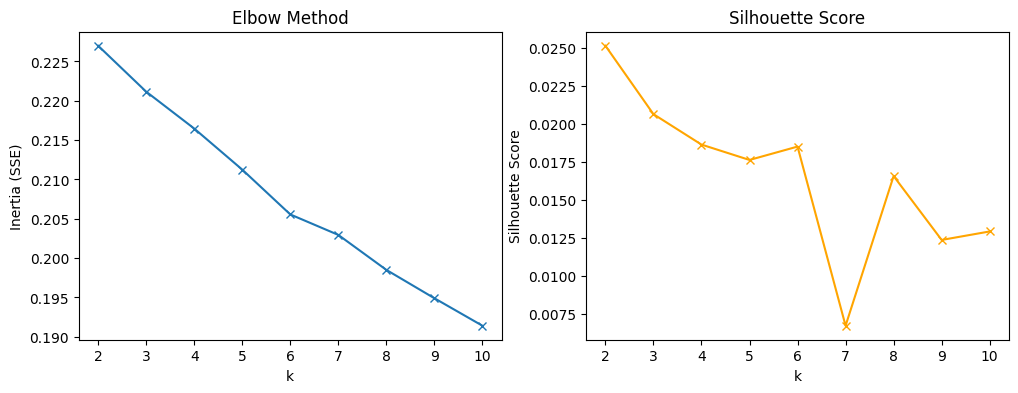

In [53]:
svd_optimal = TruncatedSVD(n_components=n_components)
vectors_reduced = svd_optimal.fit_transform(vectors)

inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(vectors_reduced)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(vectors_reduced, labels))

# Visualiser Elbow et Silhouette
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker="x")
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouettes, marker="x", color="orange")
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

Nombre optimal de clusters selon silhouette : 2


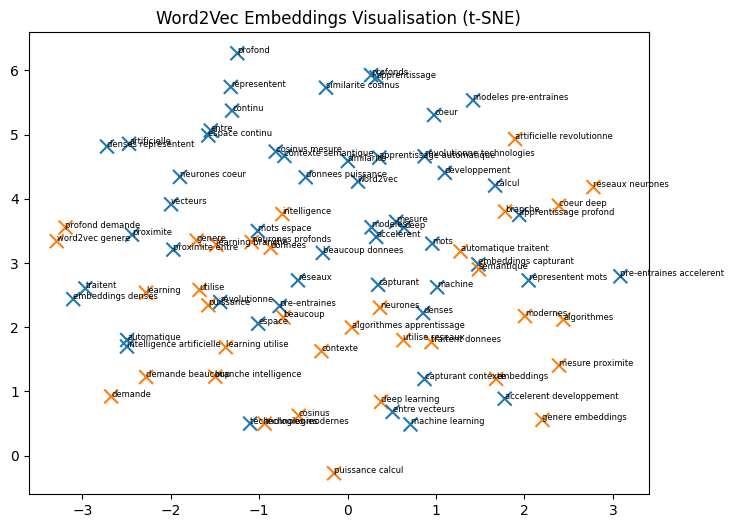

In [54]:
k_optimal = k_range[np.argmax(silhouettes)]
print(f"Nombre optimal de clusters selon silhouette : {k_optimal}")
kmeans_optimal = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans_optimal.fit_predict(vectors)

tsne = TSNE(n_components=2, random_state=42)
vectors_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(8, 6))
cmap = plt.get_cmap("tab10")
colors = [cmap(cluster) for cluster in clusters]
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=colors, s=100, marker="x")
for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=6)
plt.title("Word2Vec Embeddings Visualisation (t-SNE)")
plt.show()

### Tâche 6 : Embeddings de documents
1. Créez des embeddings de documents par moyenne des embeddings de tokens :
   ```python
   doc_embedding = moyenne(embeddings[tokens])
   ```
2. Calculez la similarité entre les 6 documents du corpus
3. Créez une matrice de similarité (heatmap)
4. Identifiez les paires de documents les plus similaires

**Attendus** : Embeddings de documents, matrice de similarité, visualisation

In [55]:
doc_embedding = []
for doc in corpus_bigram:
    doc_embedding.append(np.mean([word_to_vec_bigram.wv[word] for word in doc], axis=0))

similarities_doc = {}
for i, emb_i in enumerate(doc_embedding, 1):
    similarities_doc[f"doc_{i}"] = []
    for j, emb_j in enumerate(doc_embedding, 1):
        similarities_doc[f"doc_{i}"].append(1 - cosine(emb_i, emb_j))

similarities_doc_df = pd.DataFrame(
    data=similarities_doc,
    columns=[f"doc_{i}" for i in range(1, len(corpus_bigram) + 1)],
    index=[f"doc_{i}" for i in range(1, len(corpus_bigram) + 1)],
)
similarities_doc_df.head()

,doc_1,doc_2,doc_3,doc_4,doc_5,doc_6,doc_7,doc_8,doc_9,doc_10
doc_1,1.000000,0.333587,0.228648,0.308100,0.119116,0.180922,0.051200,0.046828,0.085180,0.074408
doc_2,0.333587,1.000000,0.048929,0.061276,0.119525,0.145829,0.019092,-0.058252,0.075540,-0.074295
doc_3,0.228648,0.048929,1.000000,0.643834,0.341961,0.199449,0.070957,0.101329,0.018305,0.043557
doc_4,0.308100,0.061276,0.643834,1.000000,0.376387,0.325728,-0.026653,0.123098,-0.097188,0.082497
doc_5,0.119116,0.119525,0.341961,0.376387,1.000000,0.255656,0.076265,0.122198,-0.005452,0.115153


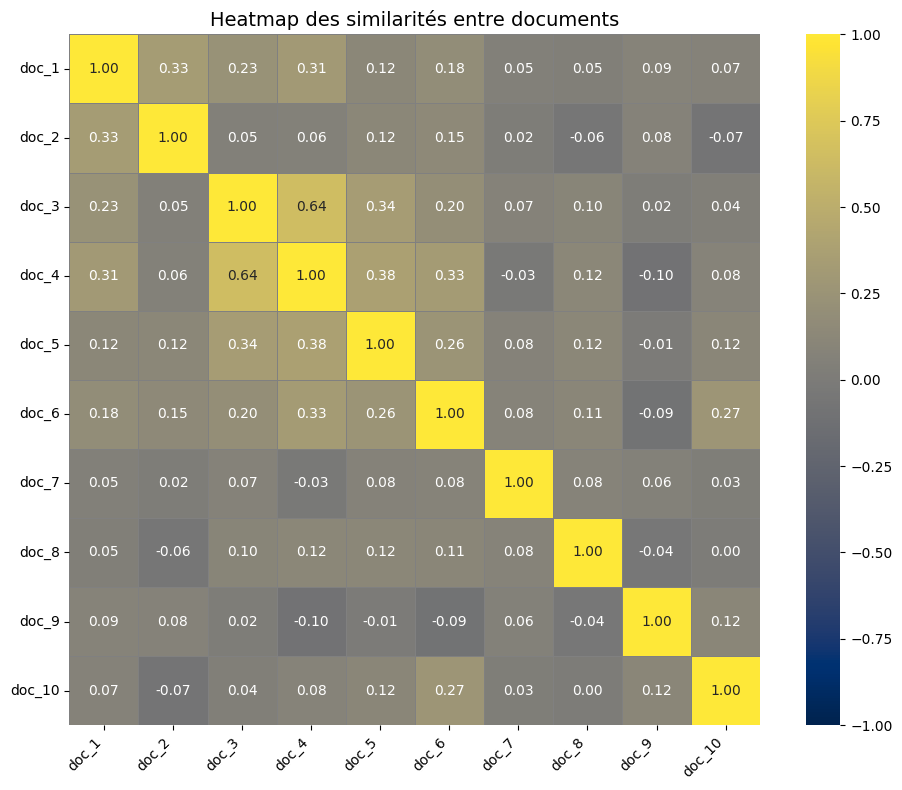

In [56]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    similarities_doc_df,
    square=True,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="cividis",
    cbar=True,
    linewidths=0.5,
    linecolor="gray",
)

plt.title("Heatmap des similarités entre documents", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Corrélation entre doc3 et doc4.

### Tâche 7 : Comparaison Word2Vec vs TF-IDF
1. Créez deux représentations d'un même document :
   - Vecteur TF-IDF (exercice 2)
   - Vecteur Word2Vec (moyenne des embeddings)
2. Calculez la similarité cosinus entre deux documents avec chaque méthode
3. Comparez : qu'apporte Word2Vec que TF-IDF n'a pas?
4. Quand utiliser l'une vs l'autre?

**Attendus** : Comparaison quantifiée, recommandations

In [57]:
tfidf = TfidfVectorizer(
    max_features=100,
    ngram_range=(1, 2),
    min_df=1,
    token_pattern=r"(?u)\b\w+(?:-\w+)*\b",  # Conserve trait d'union entre les mots
)

X_tfidf = tfidf.fit_transform(corpus_clean)

print(f"Nombre de tokens TfidfVectorizer : {len(tfidf.get_feature_names_out())}")
print(f"Nombre de tokens Word2Vec : {len(word_to_vec_bigram.wv.index_to_key)}")
print(
    f"Nombre de tokens TfidfVectorizer intersection Word2Vec : {len(set(word_to_vec_bigram.wv.index_to_key) & set(word_to_vec_bigram.wv.index_to_key))}"
)

Nombre de tokens TfidfVectorizer : 87
Nombre de tokens Word2Vec : 87
Nombre de tokens TfidfVectorizer intersection Word2Vec : 87


In [58]:
similarities_doc_tfidf = cosine_similarity(X_tfidf)

similarities_doc_tfidf_df = pd.DataFrame(
    data=similarities_doc_tfidf,
    columns=[f"doc_{i}" for i in range(1, len(corpus_bigram) + 1)],
    index=[f"doc_{i}" for i in range(1, len(corpus_bigram) + 1)],
)
similarities_doc_tfidf_df.head()

,doc_1,doc_2,doc_3,doc_4,doc_5,doc_6,doc_7,doc_8,doc_9,doc_10
doc_1,1.000000,0.272996,0.074360,0.065749,0.0,0.000000,0.0,0.0,0.0,0.0
doc_2,0.272996,1.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
doc_3,0.074360,0.000000,1.000000,0.514057,0.0,0.000000,0.0,0.0,0.0,0.0
doc_4,0.065749,0.000000,0.514057,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0
doc_5,0.000000,0.000000,0.000000,0.000000,1.0,0.140978,0.0,0.0,0.0,0.0


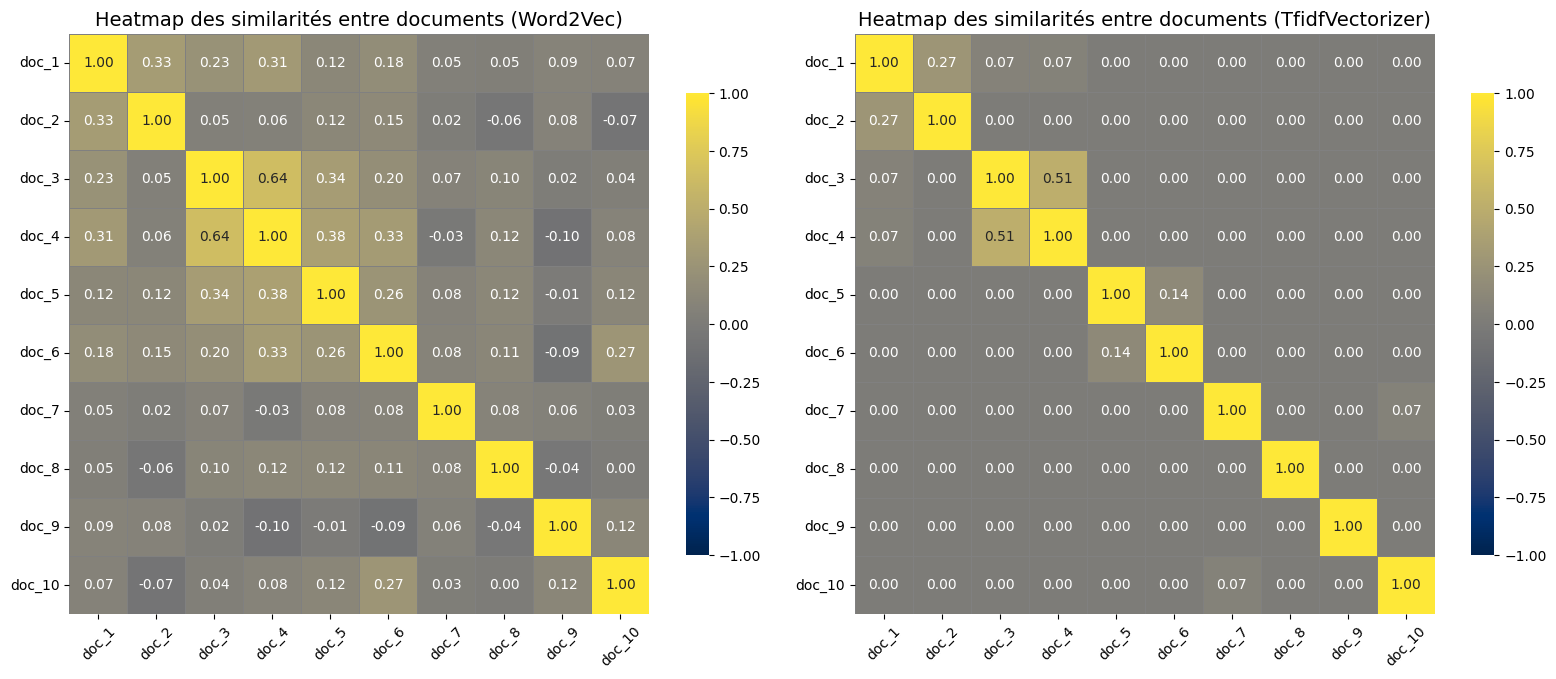

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax1 = axes[0]
sns.heatmap(
    similarities_doc_df,
    square=True,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="cividis",
    cbar=True,
    cbar_kws={"shrink": 0.6},
    linewidths=0.5,
    linecolor="gray",
    ax=ax1,
)
ax1.set_title("Heatmap des similarités entre documents (Word2Vec)", fontsize=14)
ax1.tick_params(axis="x", rotation=45)
ax1.tick_params(axis="y", rotation=0)

ax2 = axes[1]
sns.heatmap(
    similarities_doc_tfidf_df,
    square=True,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="cividis",
    cbar=True,
    cbar_kws={"shrink": 0.6},
    linewidths=0.5,
    linecolor="gray",
    ax=ax2,
)
ax2.set_title("Heatmap des similarités entre documents (TfidfVectorizer)", fontsize=14)
ax2.tick_params(axis="x", rotation=45)
ax2.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

In [60]:
X_word2vec = np.vstack(
    [
        word_to_vec_bigram.wv[word]
        if word in word_to_vec_bigram.wv
        else np.zeros(word_to_vec_bigram.vector_size)
        for word in tfidf.get_feature_names_out()
    ]
)

doc_embeddings_optimal = X_tfidf @ X_word2vec
doc_embeddings_optimal = doc_embeddings_optimal / np.maximum(X_tfidf.sum(axis=1), 1)

similarities_doc_optimal_df = pd.DataFrame(
    cosine_similarity(np.asarray(doc_embeddings_optimal)),
    index=[f"doc_{i}" for i in range(1, len(corpus_bigram) + 1)],
    columns=[f"doc_{i}" for i in range(1, len(corpus_bigram) + 1)],
)

similarities_doc_optimal_df.head(10)

,doc_1,doc_2,doc_3,doc_4,doc_5,doc_6,doc_7,doc_8,doc_9,doc_10
doc_1,1.000000,0.272068,0.191424,0.280470,0.132126,0.179613,0.055781,0.034483,0.092857,0.083729
doc_2,0.272068,1.000000,0.045946,0.055268,0.118667,0.145282,0.017424,-0.067095,0.076435,-0.073253
doc_3,0.191424,0.045946,1.000000,0.562746,0.328698,0.172845,0.080366,0.090512,0.019217,0.032686
doc_4,0.280470,0.055268,0.562746,1.000000,0.361193,0.311576,-0.028762,0.116684,-0.107185,0.079600
doc_5,0.132126,0.118667,0.328698,0.361193,1.000000,0.219345,0.072022,0.122259,0.004506,0.121056
doc_6,0.179613,0.145282,0.172845,0.311576,0.219345,1.000000,0.079763,0.113444,-0.084780,0.280734
doc_7,0.055781,0.017424,0.080366,-0.028762,0.072022,0.079763,1.000000,0.089561,0.055584,0.000971
doc_8,0.034483,-0.067095,0.090512,0.116684,0.122259,0.113444,0.089561,1.000000,-0.042166,0.007541
doc_9,0.092857,0.076435,0.019217,-0.107185,0.004506,-0.084780,0.055584,-0.042166,1.000000,0.113712
doc_10,0.083729,-0.073253,0.032686,0.079600,0.121056,0.280734,0.000971,0.007541,0.113712,1.000000


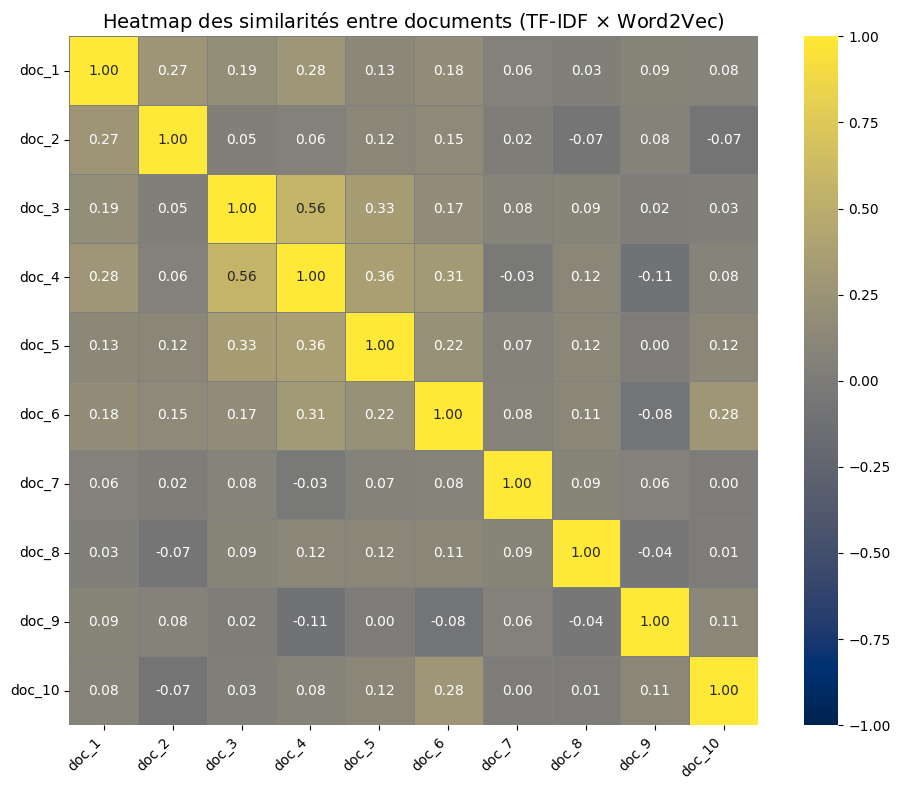

In [61]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    similarities_doc_optimal_df,
    square=True,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="cividis",
    cbar=True,
    linewidths=0.5,
    linecolor="gray",
)

plt.title(
    r"Heatmap des similarités entre documents (TF-IDF $\times$ Word2Vec)", fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

* TF-IDF mesure l’importance d’un mot dans un document par rapport à un ensemble de documents. Il produit des vecteurs creux et ne comprend pas le sens des mots : chaque mot est traité indépendamment.
* Word2Vec produit des vecteurs denses où les mots ayant des contextes similaires ont des représentations proches, ce qui permet de capturer des relations sémantiques.

## Bonus (Optionnel)

- Entraînez sur un corpus plus grand (Wikipedia, news, etc.)
- Explorez GloVe comme alternative à Word2Vec
- Implémentez le contexte personnalisé (skip-gram manuel)
- Utilisez des embeddings pré-entraînés (FastText, Word2Vec Google)
- Comparez l'impact de `vector_size` (50, 100, 300) sur la qualité